In [20]:
import pandas as pd

df_movies = pd.read_csv("D:\\Projects\\ML\\pet-recommendation\\datasets\\movies.dat",
                        sep='::', engine='python',
                        encoding="Latin-1",
                        names=['movie_id', 'title', 'genre'])

df_rating = pd.read_csv("D:\\Projects\\ML\\pet-recommendation\\datasets\\ratings.dat",
                        sep='::', engine='python',
                        encoding="Latin-1",
                        names=['user_id', 'movie_id', 'rating', 'timestamp'])

df_users = pd.read_csv("D:\\Projects\\ML\\pet-recommendation\\datasets\\users.dat",
                       sep='::', engine='python',
                       encoding="Latin-1",
                       names=["user_id", "gender", "age_group", "occupation", "zip_code"])

In [ ]:
print("Users duplicates:", df_users.duplicated().sum())
print("Ratings duplicates:", df_rating.duplicated().sum())
print("Movies duplicates:", df_movies.duplicated().sum())
print("Duplicate ratings for user-movie pairs:", df_rating.duplicated(["user_id", "movie_id"]).sum())   

Users duplicates: 0
Ratings duplicates: 0
Movies duplicates: 0
Duplicate ratings for user-movie pairs: 0


дубликаты отсутствуют

### Users

In [4]:
df_users.head()

,user_id,gender,age_group,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


Из интересного в таблице наблюдаю пол, возрастную группу и професия (нам она не известна, но для модели может быть полезно)

In [26]:
print(df_users.info())

print(df_users.describe())

<class 'pandas.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     6040 non-null   int64
 1   gender      6040 non-null   str  
 2   age_group   6040 non-null   int64
 3   occupation  6040 non-null   int64
 4   zip_code    6040 non-null   str  
dtypes: int64(3), str(2)
memory usage: 236.1 KB
None
           user_id    age_group   occupation
count  6040.000000  6040.000000  6040.000000
mean   3020.500000    30.639238     8.146854
std    1743.742145    12.895962     6.329511
min       1.000000     1.000000     0.000000
25%    1510.750000    25.000000     3.000000
50%    3020.500000    25.000000     7.000000
75%    4530.250000    35.000000    14.000000
max    6040.000000    56.000000    20.000000


In [ ]:
df_users.isnull().sum()

user_id       0
gender        0
age_group     0
occupation    0
zip_code      0
dtype: int64

очищение данных не требуется (отсутствуют null значения) в возрастной группе преобладают люди до 25 лет

In [61]:
counts = df_users.age_group.value_counts().sort_index()
norms = df_users.age_group.value_counts(normalize=True).sort_index()

res = pd.concat([counts, norms], axis=1, keys=['counts', 'norms']).reset_index().sort_values(by='norms', ascending=False)

res

,age_group,counts,norms
2,25,2096,0.347020
3,35,1193,0.197517
1,18,1103,0.182616
4,45,550,0.091060
5,50,496,0.082119
6,56,380,0.062914
0,1,222,0.036755


В выборке преобладают пользователи младших возрастных групп

### Rating

In [28]:
df_rating.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [29]:
df_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [30]:
df_rating.describe()

,user_id,movie_id,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


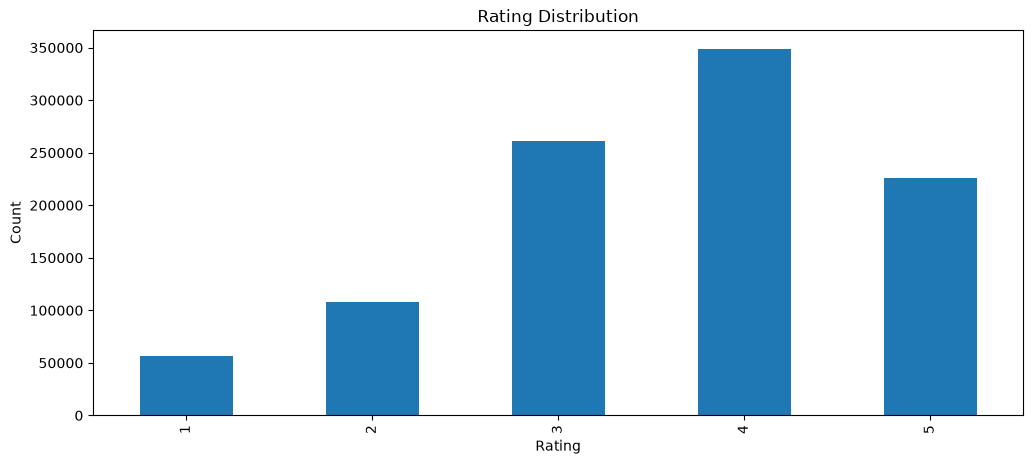

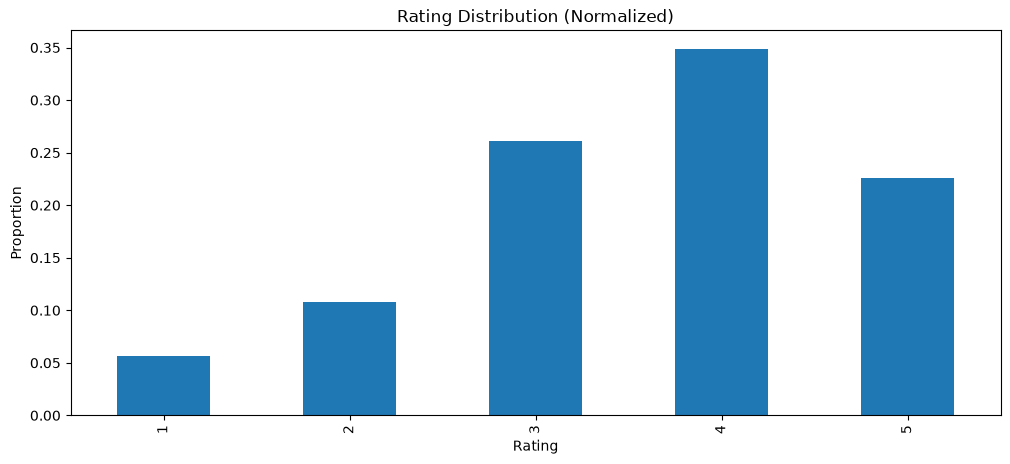

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64
rating
1    0.056162
2    0.107535
3    0.261142
4    0.348898
5    0.226263
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

tmp = df_rating.rating.value_counts().sort_index()
tmp_norm = df_rating.rating.value_counts(normalize=True).sort_index()

plt.figure(figsize=(12, 5))
tmp.plot(kind='bar', title='Rating Distribution', xlabel='Rating', ylabel='Count')

plt.figure(figsize=(12, 5))
tmp_norm.plot(kind='bar', title='Rating Distribution (Normalized)', xlabel='Rating', ylabel='Proportion')

plt.show()

print(tmp)
print(tmp_norm)

In [ ]:
print(f"Sum rating 1-3: {tmp.iloc[0:3].sum()}")
print(f"Sum rating 4-5: {tmp.iloc[3:5].sum()}")

Sum rating 1-3: 424928
Sum rating 4-5: 575281


Положительные оценки (4–5) встречаются чаще отрицательных (1–3).

In [31]:
df_rating.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

На основе пользовательский рейтингов можно будет сформировать матрицу пользователь-фильм и применить матричную факторизацию для выявления скрытых предпочтений пользователей

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: count, dtype: float64

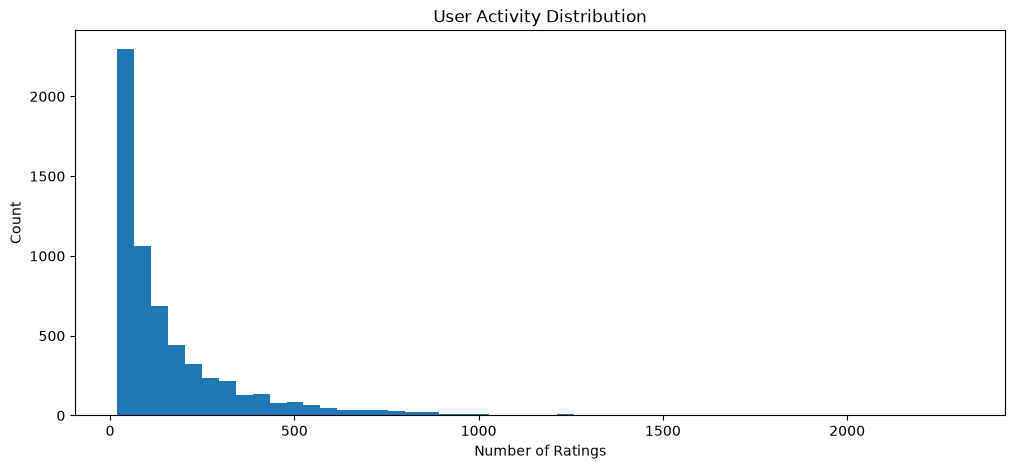

In [73]:
user_activity = df_rating.user_id.value_counts()

user_activity.plot(kind="hist", bins=50, figsize=(12, 5), title="User Activity Distribution", xlabel="Number of Ratings", ylabel="Count")

user_activity.describe()

In [74]:
user_activity[user_activity > 2000].count()


np.int64(1)

Наблюдаются пользователи с существенно большей активностью: отдельные пользователи оставили более 1000 оценок. Максимальное количество оценок одного пользователя составляет 2314.

In [78]:
movies_activity = df_rating.movie_id.value_counts()

movies_activity.describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
Name: count, dtype: float64

In [79]:
movies_activity.head(10)

movie_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578
Name: count, dtype: int64

<Axes: title={'center': 'Movie Activity Distribution'}, xlabel='Number of movie', ylabel='Count'>

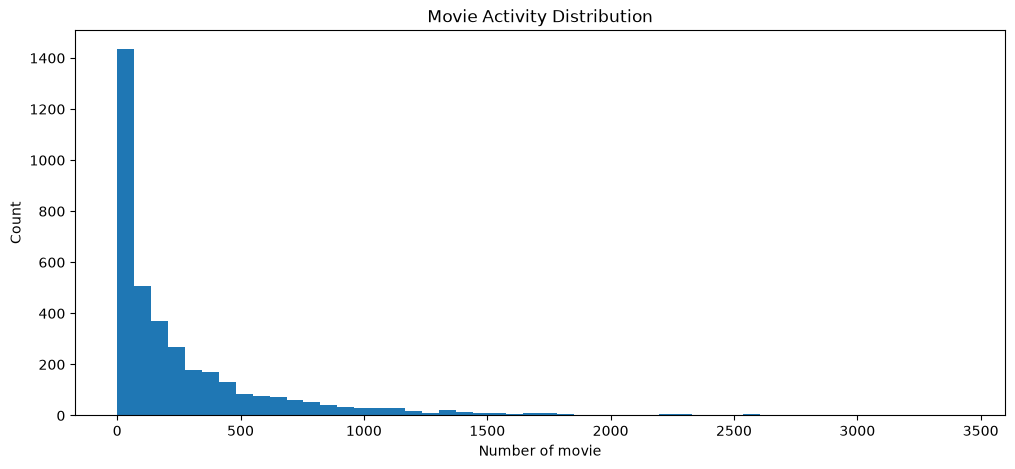

In [ ]:
movies_activity.plot(kind="hist", bins=50, figsize=(12, 5), title="Movie Activity Distribution", xlabel="Number of Ratings", ylabel="Count")

### Movies

In [6]:
df_movies.head()

,movie_id,rating,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


Жанры точно надо будет использовать при постоении модели. Но перед этим преобразовать их в список или в другой нормальный вид

In [32]:
df_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  3883 non-null   int64
 1   title     3883 non-null   str  
 2   genre     3883 non-null   str  
dtypes: int64(1), str(2)
memory usage: 91.1 KB


In [34]:
df_movies.isnull().sum()

movie_id    0
title       0
genre       0
dtype: int64

In [65]:
genre_counts = (
    df_movies.genre
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts

genre
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Name: count, dtype: int64

<Axes: title={'center': 'Genre Distribution'}, xlabel='Genre', ylabel='Count'>

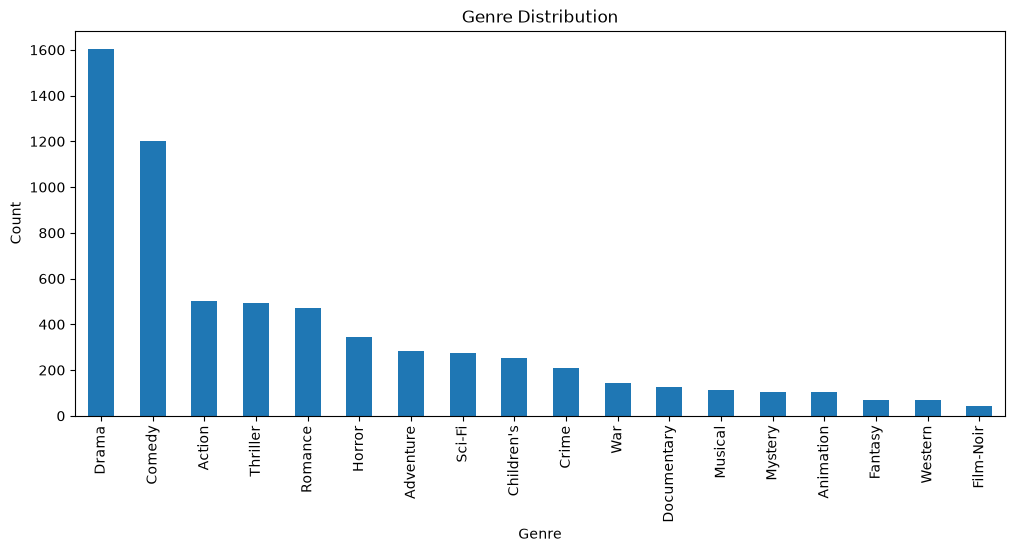

In [66]:
genre_counts.plot(kind="bar", figsize=(12, 5), title="Genre Distribution", xlabel="Genre", ylabel="Count")

Наибольшее количество фильмов приходится на жанры Drama, Comedy, Action, Thriller и Romance.

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
Name: count, dtype: float64